In [2]:
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [1]:
data = {
    "Area": [800, 950, 1100, 1200, 1350, 1500, 1650, 1800, 2000, 2200],
    "Bedrooms": [2, 2, 3, 3, 3, 4, 4, 4, 5, 5],
    "YearsOld": [15, 12, 10, 8, 7, 6, 5, 4, 3, 2],
    "Price": [120000, 140000, 165000, 180000, 200000, 230000, 260000, 290000, 330000, 370000]
}


In [3]:
df = pd.DataFrame(data)
df

,Area,Bedrooms,YearsOld,Price
0,800,2,15,120000
1,950,2,12,140000
2,1100,3,10,165000
3,1200,3,8,180000
4,1350,3,7,200000
5,1500,4,6,230000
6,1650,4,5,260000
7,1800,4,4,290000
8,2000,5,3,330000
9,2200,5,2,370000


In [5]:
X = df[["Area", "Bedrooms", "YearsOld"]]
X

,Area,Bedrooms,YearsOld
0,800,2,15
1,950,2,12
2,1100,3,10
3,1200,3,8
4,1350,3,7
5,1500,4,6
6,1650,4,5
7,1800,4,4
8,2000,5,3
9,2200,5,2


In [6]:
y = df["Price"]

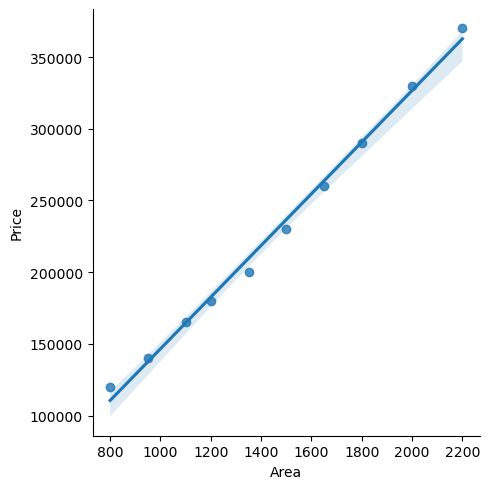

In [9]:
sns.lmplot(x="Area", y="Price", data=df)

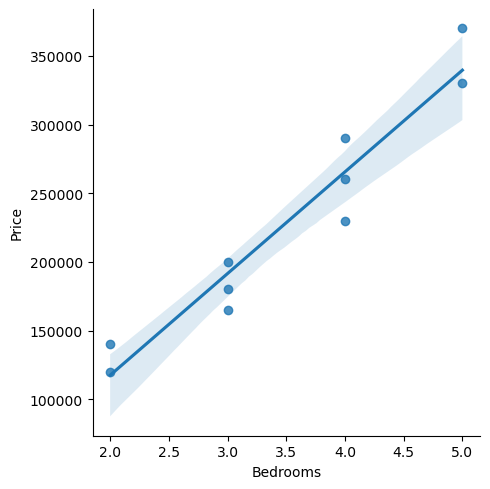

In [12]:
sns.lmplot(x="Bedrooms", y="Price", data=df)

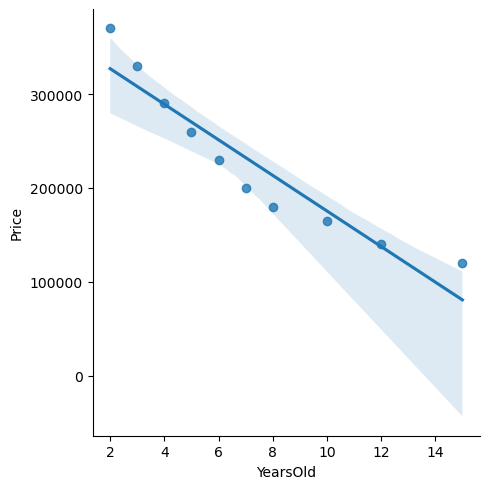

In [13]:
sns.lmplot(x="YearsOld", y="Price", data=df)

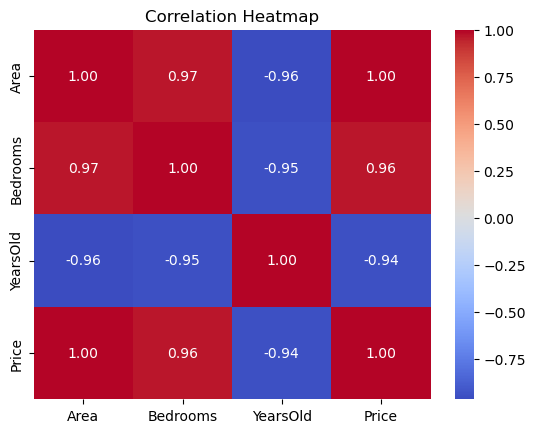

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# select numeric columns
corr = df[['Area', 'Bedrooms', 'YearsOld', 'Price']].corr()

# plot heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
corr['Price'].sort_values(ascending=False)


Price       1.000000
Area        0.997442
Bedrooms    0.964388
YearsOld   -0.944369
Name: Price, dtype: float64

In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = df[['Area', 'Bedrooms', 'YearsOld']]

vif = pd.DataFrame()
vif['Feature'] = X.columns
vif['VIF'] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]
vif


,Feature,VIF
0,Area,200.920508
1,Bedrooms,204.800457
2,YearsOld,2.070376


In [21]:
X = df[['Area', 'YearsOld']]
y = df['Price']


In [22]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

pd.Series(model.coef_, index=X.columns)


Area         223.215855
YearsOld    4961.803183
dtype: float64

In [23]:
from sklearn.metrics import r2_score

y_pred = model.predict(X)
r2_score(y, y_pred)


0.9991840180153114

In [24]:
X = df[['Area', 'Bedrooms', 'YearsOld']]


In [25]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X, y)

pd.Series(ridge.coef_, index=X.columns)


Area         219.042783
Bedrooms     271.094011
YearsOld    4552.042520
dtype: float64

In [26]:
from sklearn.metrics import r2_score

r2_score(y, ridge.predict(X))


0.9991578610156029